# Three integration paths on smooth RuO₂/TiO₂ CTRs

This diagnostic accompanies [issue #82](https://github.com/tifuchs/orGUI/issues/82).
It generates detector frames for a **flat RuO₂(110) film on TiO₂(110)**, then
compares stationary ROI integration, rocking integration, and native HKL-map
integration. Every plotted output is computed below; there is no external data
file, fitted scale, roughness distribution, or imported test fixture.

The first integration comparison uses the continuous film CTR with photon noise
and three background types, using the actual app extraction/reduction and reconstruction routines.
Stationary and rocking have their saved error bars. **The current HKL-map
integration API supplies no integrated uncertainty, so its points have no error
bars.** The native backprojection prototype is not used. A separate local-constant control isolates normalization. The final
diagnostic shows why different resolution functions need not recover the same
point value when the CTR varies across their apertures.

**Run all cells** with an orGUI installation containing its native reconstruction
extension, plus Jupyter and Matplotlib. Expected runtime is several minutes.
The executed outputs are saved so documentation builds do not run the simulation.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from types import SimpleNamespace
from tempfile import TemporaryDirectory
import importlib
import logging
import sys

# Keep routine DEBUG/INFO logs out of notebook output; retain warnings and errors.
logging.disable(logging.INFO)

# Support both a source checkout and an installed orGUI wheel.
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "pyproject.toml").is_file() and (parent / "orgui").is_dir():
        sys.path.insert(0, str(parent))
        break

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import HTML, display
import pyFAI
import orgui
from orgui.app import integration_corrections as ic
from orgui.app.config_data import CorrectionState
from orgui.backend.scans import h5_Image
from orgui.datautils.xrayutils import CTRcalc, CTRfilm, HKLVlieg, DetectorCalibration
from orgui.datautils.xrayutils.corrections import detector as detector_corrections
from orgui.datautils.xrayutils.corrections import measurement
from orgui.datautils.xrayutils.reconstruction import (
    _GridSpec, _ReconstructionSpec, _CheckpointRouter, _build_kernels,
    _tile_ray_arrays, _map_frame_group, _finalize_reconstruction,
)
from orgui.reconstruction_job import _correction_pipeline

try:
    importlib.import_module("orgui.datautils.xrayutils._reciprocal_reconstruction_cpp")
except ImportError as error:
    raise RuntimeError("Install an orGUI wheel with native reconstruction, or rebuild with Meson.") from error

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
print(f"orGUI {orgui.__version__}; NumPy {np.__version__}; pyFAI {pyFAI.version}")

orGUI 1.5.1.dev342+gabf4aeff0.d20261001; NumPy 2.5.3; pyFAI 2026.5.0


## Explicit smooth film model

The right-handed surface axes are $[1\bar10]$, $[00\bar1]$, $[110]$. The reference TiO₂ cell is
$(a_s,b_s,c_s)=(6.5807,2.9692,6.5807)$ Å, with 90° angles. The coherent film has
the same lateral cell and $c_f=6.5657$ Å. These illustrative strained-cell
parameters and oxygen coordinates follow the repository's ideal RuO₂/TiO₂
example; this is a diagnostic model, not a fit to a measured specimen.

Each surface cell has four metal atoms and eight oxygen atoms, generated from
the conventional rutile basis with oxygen $u=0.30458$ (Ti) or $0.30569$ (Ru).
The substrate cell has $-1<z\leq0$ and the film cell $0<z\leq1$: their sharp
boundaries do not double-count an atomic plane. Eight full film repeats give
a nominal thickness of 52.5256 Å. Occupancies are one and Debye–Waller parameters
are zero. A plain `Film` supplies a deterministic thickness; no `PoissonSurface`
or broadened epitaxy interface is used.

The bulk attenuation exponent is 0.01 per reference repeat, regularizing the
kinematic substrate Bragg poles; it is **not roughness**. The calculations and
geometry use 17.7 keV. $F$ is in electrons per reference lateral cell and
$|F|^2$ in electrons². Exact bulk Bragg positions are avoided in the detector tests.

In [2]:
ENERGY_KEV = 17.7
N_FILM_CELLS = 8
RODS = [(2, 0), (1, 1)]

def _rutile_110_cell(metal, u, c_surface, *, substrate):
    '''Build an explicit rutile (110) surface cell in Angstrom and fractional coordinates.'''
    cell = CTRcalc.UnitCell([6.5807, 2.9692, c_surface], [90, 90, 90], name=metal + "O2")
    parent = [
        (metal, (0, 0, 0)), (metal, (0.5, 0.5, 0.5)),
        ("O", (u, u, 0)), ("O", (1-u, 1-u, 0)),
        ("O", (0.5-u, 0.5+u, 0.5)), ("O", (0.5+u, 0.5-u, 0.5)),
    ]
    for translation in (0, 1):
        for element, (x, y, z) in parent:
            x += translation
            xyz = np.mod([(x-y)/2, -z, (x+y)/2], 1.0)
            if substrate:
                xyz[2] = xyz[2] - 1 if xyz[2] > 1e-12 else 0
            elif xyz[2] < 1e-12:
                xyz[2] = 1
            cell.addAtom(element, xyz, 0.0, 0.0, 1.0, layer=0)
    assert len(cell.names) == 12 and cell.names.count("O") == 8
    return cell

bulk = _rutile_110_cell("Ti", 0.30458, 6.5807, substrate=True)
film_cell = _rutile_110_cell("Ru", 0.30569, 6.5657, substrate=False)
film = CTRfilm.Film(film_cell, name="flat_RuO2")
film.basis[0] = N_FILM_CELLS  # one structural layer here is a full surface cell
film.basis_0[:] = film.basis
crystal = CTRcalc.SXRDCrystal(bulk, film, stacking=np.array([1]), atten=0.01)
crystal.setEnergy(ENERGY_KEV)
crystal.apply_stacking()
substrate = CTRcalc.SXRDCrystal(bulk, atten=0.01)
substrate.setEnergy(ENERGY_KEV)

ub = HKLVlieg.UBCalculator(bulk, ENERGY_KEV)
ub.defaultU_GID()
angles = HKLVlieg.VliegAngles(ub)
AREA_ANGSTROM2 = bulk.uc_area
print(f"Reference area: {AREA_ANGSTROM2:.6f} Å²")
print(f"Film thickness: {film.height_absolute:.4f} Å ({film.height_absolute/10:.4f} nm)")
assert np.isclose(film.height_absolute, N_FILM_CELLS * film_cell.a[2])

def _f2(hk, ell):
    '''Return the film/substrate CTR intensity on the reference-cell electron² scale.'''
    ell = np.atleast_1d(ell)
    return crystal.F2(np.full_like(ell, hk[0]), np.full_like(ell, hk[1]), ell)

L_CURVE = np.linspace(0.65, 3.65, 6001)
curve_f2 = {hk: _f2(hk, L_CURVE) for hk in RODS}

Reference area: 19.539414 Å²
Film thickness: 52.5256 Å (5.2526 nm)


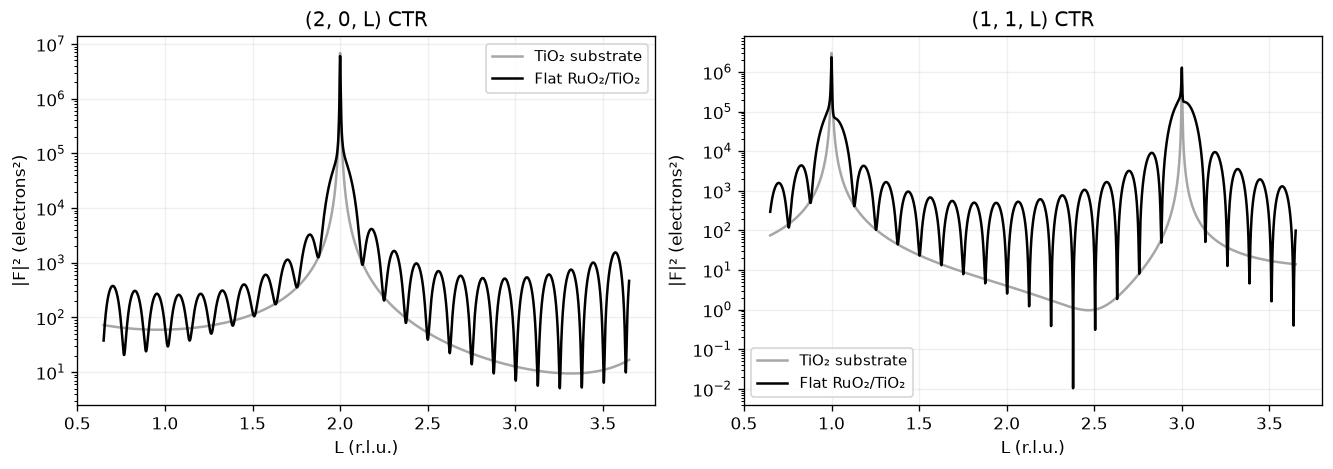

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for ax, hk in zip(axes, RODS):
    bare = substrate.F2(np.full_like(L_CURVE, hk[0]), np.full_like(L_CURVE, hk[1]), L_CURVE)
    ax.semilogy(L_CURVE, bare, color="0.65", label="TiO₂ substrate")
    ax.semilogy(L_CURVE, curve_f2[hk], color="black", label="Flat RuO₂/TiO₂")
    ax.set(title=f"({hk[0]}, {hk[1]}, L) CTR", xlabel="L (r.l.u.)", ylabel="|F|² (electrons²)")
    ax.legend(fontsize=9)
plt.show()

## Forward detector data and unit boundaries

For each target $(h_0,k_0,L_0)$ the transverse rod profile is

$$g(h,k)=\frac{\exp[-((h-h_0)^2+(k-k_0)^2)/(2\sigma_{hk}^2)]}{2\pi\sigma_{hk}^2},
\qquad\sigma_{hk}=0.0006\ \mathrm{r.l.u.}$$

Its integral over $h,k$ is one. The expected photons in a pixel are generated
independently from the reduction helpers:

$$N_{ip}=Q_i H\frac{r_e^2}{A_u}\,|F|^2 g(h_p,k_p)P_p\Omega_p.$$

$r_e=2.8179403262\times10^{-15}$ m, $A_u$ is converted from Å² to m², and
$\Omega_p$ is the **absolute** flat-pixel solid angle in steradians. The virtual
detector is 4 m from the sample, with 172 µm row pitch and 57.333 µm column pitch.
The finer horizontal sampling resolves the peak in the TiO₂ reciprocal basis;
this is a simulated detector, not a commercial detector specification.
Nine midpoint samples average each finite rocking
exposure. Exposure and relative incident flux vary across the scan; the primary
monitor is a rate. A 1 mm sample, centered in a 0.769231 mm top-hat vertical beam with full
horizontal interception, gives $H=1.3$. The actual footprint policy resolves
this divisor for the angular paths; the constant is supplied explicitly to the
map structure-factor scripting API.

The forward generator returns deterministic expected photon counts. The next
cells sample signal and background photons from these means for the noise
study; the separate normalization control keeps the expected counts. No
readout noise is introduced.
Native mapping applies the real exposure/monitor, polarization and relative
solid-angle correction pipeline. It maps finite exposure intervals, writes
checkpoints, and finalizes HDF5 voxel means. All temporary files are deleted
after their plotted arrays are read.

In [4]:
@dataclass
class _Scan:
    exposure_time: np.ndarray
    monitor: np.ndarray
    auxillary_counters = ("monitor",)

    def __len__(self):
        return self.exposure_time.size

def _simulate(hk, ell, f2):
    '''Generate physical expected photon frames with local constant CTR intensity.'''
    position = angles.anglesZmode(np.array([[hk[0]], [hk[1]], [ell]]), np.deg2rad(0.6), fixed="in")[0]
    alpha, delta, gamma, omega, chi, phi = position
    _, dp, gp, *_ = HKLVlieg.primBeamAngles(position)
    shape, pixel_row, pixel_column, distance = (241, 483), 172e-6, 172e-6/3, 4.0
    detector = DetectorCalibration.Detector2D_SXRD()
    detector.detector = pyFAI.detectors.Detector(pixel1=pixel_row, pixel2=pixel_column, max_shape=shape)
    detector.poni1, detector.poni2 = np.asarray(shape) * np.array([pixel_row, pixel_column]) / 2
    detector.dist = distance
    detector.rot1 = detector.rot2 = detector.rot3 = 0.0
    detector.setAzimuthalReference(np.pi/2)
    detector.setPolarization(0.0, 1.0)
    detector.rot1, detector.rot2, detector.rot3 = detector.paramAtArm(float(gp), float(dp))[3:6]
    detector.setArmReference(gamma_arm=float(gp), delta_arm=float(dp))
    detector.reset()
    detector._cached_array = {}
    rows, columns = np.indices(shape, dtype=float)
    gg, dd = detector.surfaceAnglesPoint(rows, columns, alpha)
    yy = (rows + 0.5) * pixel_row - detector.poni1
    xx = (columns + 0.5) * pixel_column - detector.poni2
    solid_angle = pixel_row*pixel_column * distance / (distance**2 + xx**2 + yy**2)**1.5
    polarization = 1 - (np.sin(alpha)*np.cos(dd)*np.cos(gg) + np.cos(alpha)*np.sin(gg))**2
    np.testing.assert_allclose(detector.polarizationArray(), polarization, rtol=2e-7)

    axis = np.linspace(-0.012, 0.012, 161)  # radians; covers both transverse HK axes
    exposure = np.linspace(0.3, 1.0, axis.size)
    relative_flux = 1 + 0.19*np.sin(axis/0.001)
    flux, reference, illumination = 3.7e10, 1.8e6, 1.3
    fluence = flux * exposure * relative_flux
    scan = _Scan(exposure, reference*relative_flux)
    state = CorrectionState(
        use_normalization=True, shared_frame_normalization=True,
        use_solid_angle=True, use_polarization=True,
        total_incident_flux=flux, total_flux_calibrated=True,
        primary_monitor="monitor", primary_monitor_kind="rate",
        primary_monitor_unit="counts/s", monitor_reference_reading=reference,
    )
    radius_m, area_m2, sigma = 2.8179403262e-15, AREA_ANGSTROM2*1e-20, 0.0006
    prefactor = radius_m**2 / area_m2
    angular_scale = radius_m**2 * (ub.getLambda()*1e-10)**2 / area_m2**2
    half_step = (axis[1]-axis[0])/2
    offsets = ((np.arange(9)+0.5)/9-0.5)*2*half_step
    raw, bounds = [], []
    for i, offset in enumerate(axis):
        density = np.zeros(shape)
        for suboffset in offsets:
            h, k, l_pixel = angles.anglesToHkl(alpha, dd, gg, omega+offset+suboffset, chi, phi)
            density += np.exp(-((h-hk[0])**2+(k-hk[1])**2)/(2*sigma**2))
        density /= 9*2*np.pi*sigma**2
        raw.append(fluence[i]*illumination*prefactor*f2*density*polarization*solid_angle)
        bounds.append([[alpha, omega+offset-half_step, chi, phi], [alpha, omega+offset+half_step, chi, phi]])
    return SimpleNamespace(
        hk=hk, ell=ell, target=f2, detector=detector, scan=scan, state=state,
        raw=np.array(raw), bounds=np.array(bounds), axis=axis, position=position,
        fluence=fluence, polarization=polarization, illumination=illumination,
        angular_scale=angular_scale, omega_ref=pixel_row*pixel_column/distance**2, l_pixel=l_pixel,
    )

def _expected_roi_trace(data):
    """Display expected counts with the app's ROI-mean polarization convention."""
    inverse_polarization = detector_corrections.pixel_factors(data.detector, polarization=True)
    roi = np.s_[100:141, 201:282]
    factor = ic.roi_mean_correction(inverse_polarization[roi].sum(), 41*81)
    counts = data.raw[:, 100:141, 201:282].sum(axis=(1, 2))
    _, _, ctr_counts, _ = ic.pixel_correction_branches(counts, np.zeros_like(counts), factor, factor)
    return ctr_counts/data.fluence/data.illumination


## Shared detector frames, integration boundaries and Poisson backgrounds

The nine images below show **three frames from one (1,1,2.35) rocking scan**
under three background conditions. Columns are the same exposures in every row.
The white contour marks half the expected peak height, making the rod crossing
visible even in noisy images. It is a guide, not an integration boundary.

The blue rectangle on the central image is the stationary ROI: rows 90–150
and columns 201–281 inclusive. The orange dashed rectangle is the rocking
ROI: rows 100–140 and columns 201–281 inclusive, applied to every frame. The trace underneath shows
how the moving signal enters and leaves that aperture. Vertical gray lines mark
the rocking integration limits, −0.012 to +0.012 radians; colored lines locate
the three displayed frames. Angles are displayed in degrees.

The background means $B_p$, in photons per pixel per exposure, are:

1. **No background:** $B_p=0$ (signal photon shot noise is still present).
2. **Uniform:** $B_p=1$ throughout the detector.
3. **Oblique gradient:** $B_p$ increases linearly from 0.2 to 1.8 in a direction
   30° from increasing detector column toward increasing detector row. The angle
   is defined in the physical detector plane, accounting for the unequal pixel
   pitches; rows increase upward in these plots. Its detector-wide mean is one.
   With centered coordinates $x,y$ in meters, this is
   $B=1+0.8(x\cos30^\circ+y\sin30^\circ)/M$, where $M$ is the largest absolute
   projection on the detector.

We draw one shared signal realization $X_{ip}\sim\mathrm{Poisson}(S_{ip})$ and
add independent backgrounds $Y_{ip}\sim\mathrm{Poisson}(B_p)$, so each displayed
image is $X+Y$. The RNG seed is fixed. All three cases have the same signal,
exposure and geometry; only their background changes.

**SNR convention:** the uniform-background *peak pixel* has
$\mathrm{SNR}=S/\sqrt{S+B}=1$ in the central exposure. For $B=1$ this requires
$S=(1+\sqrt5)/2\simeq1.618$ photons. We increase all exposure times and incident
fluences by the same factor to reach that count level. This changes photon
statistics, not the structure factor. SNR of the summed ROI is a different
quantity. The gradient case has approximately the same SNR near the center.

These are samples of the complete noisy scans passed to all three integration
techniques below. Their signal follows the continuous film CTR within each
aperture. The separate noiseless control later isolates normalization. Background is added in detector-count space,
before polarization, monitor or solid-angle correction.


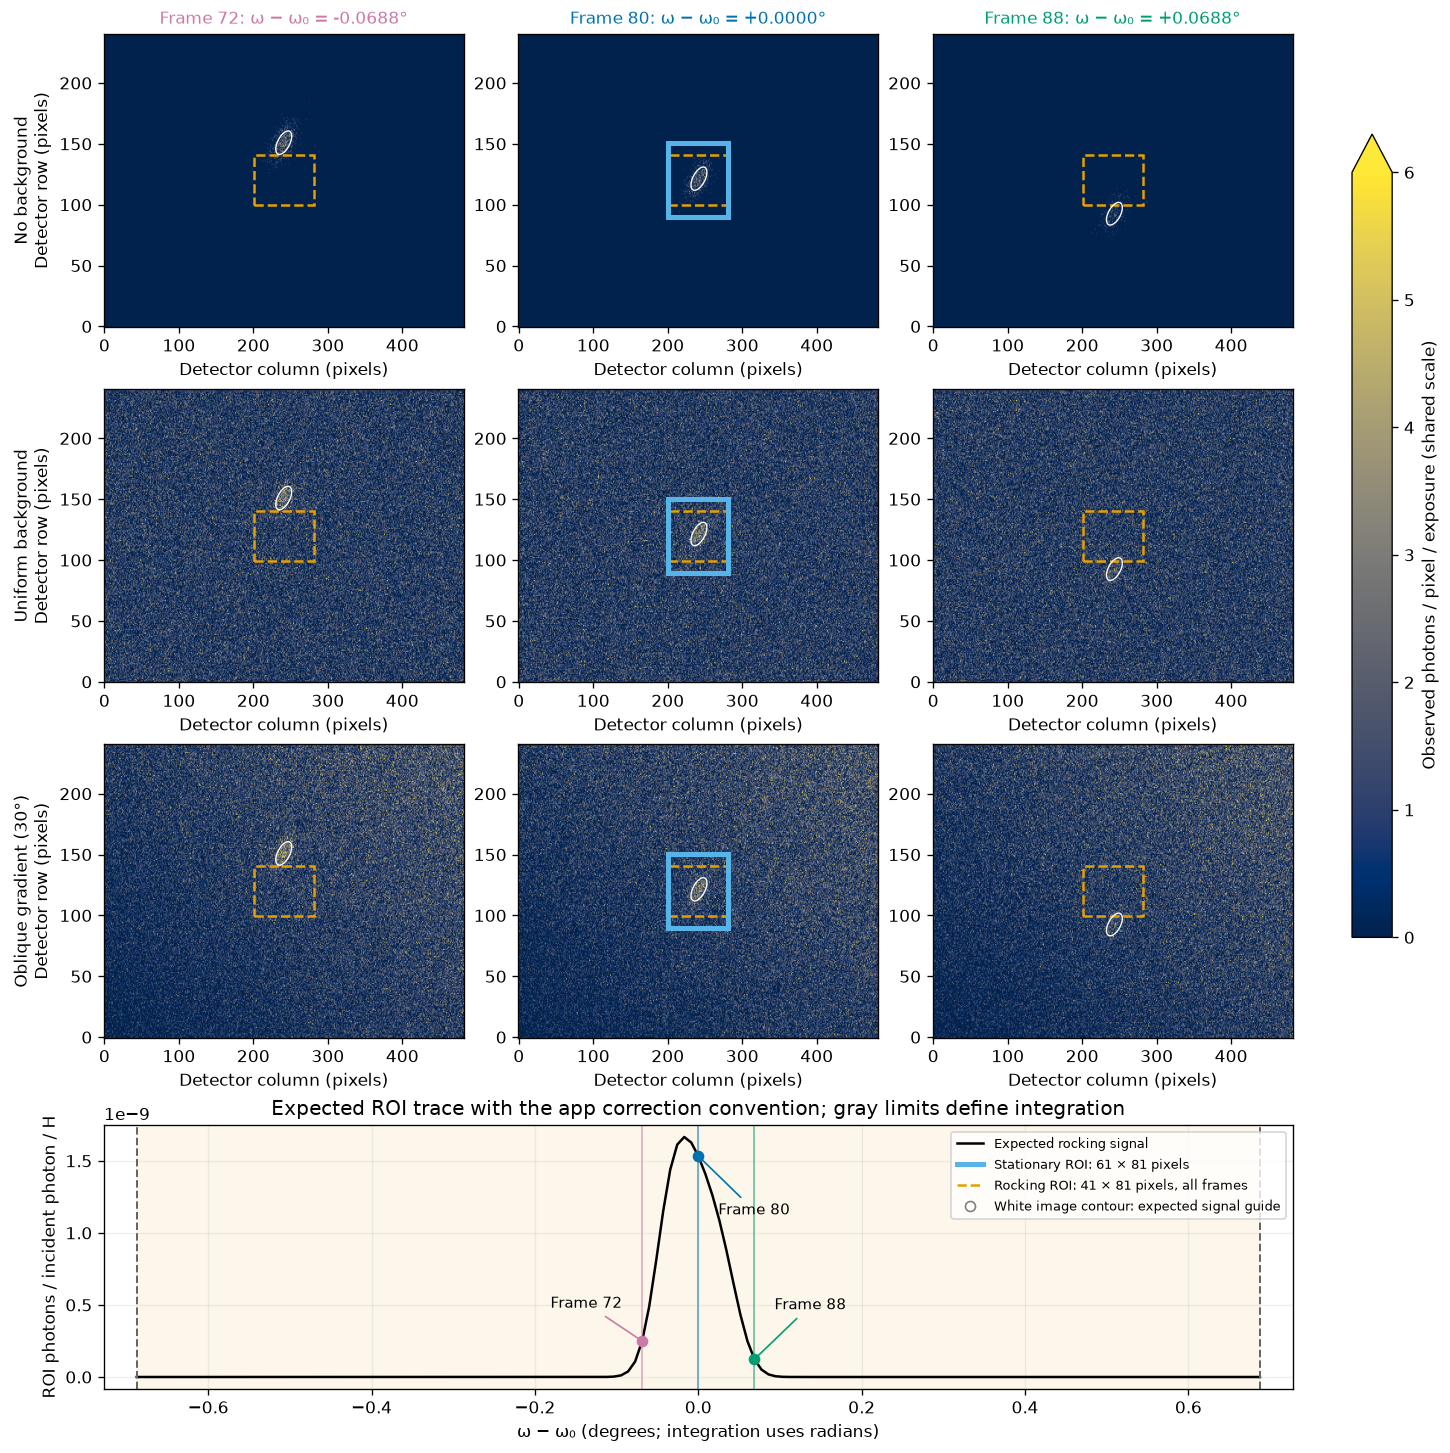

Exposure multiplier: 13.692216; central exposure: 8.900 s
Central expected peak: 1.618034 photons/pixel; uniform background: 1 photon/pixel; peak-pixel SNR: 1.000000
These are shared signal frames with three additive Poisson background models.


In [5]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

illustration_data = _simulate((1, 1), 2.35, float(_f2((1, 1), 2.35)[0]))
central_frame = len(illustration_data.scan)//2
peak_signal = (1 + np.sqrt(5))/2  # solves S/sqrt(S+1) = 1
# The explanatory frames now contain the continuous film CTR, not a local constant.
noise_pixel_f2 = _f2((1, 1), illustration_data.l_pixel.ravel()).reshape(illustration_data.l_pixel.shape)
noise_expected = illustration_data.raw * noise_pixel_f2[None, :, :] / illustration_data.target
dose_factor = peak_signal / noise_expected[central_frame].max()
illustration_data.raw *= dose_factor
illustration_data.fluence *= dose_factor
illustration_data.scan.exposure_time *= dose_factor

frame_indices = np.array([central_frame-8, central_frame, central_frame+8])
noise_reference_data = SimpleNamespace(**(vars(illustration_data) | {
    "raw": noise_expected*dose_factor,
    "scan": _Scan(illustration_data.scan.exposure_time.copy(), illustration_data.scan.monitor.copy()),
    "fluence": illustration_data.fluence.copy(),
}))
expected_frames = noise_reference_data.raw[frame_indices]
height, width = expected_frames.shape[1:]
gradient_angle_deg = 30.0
gradient_angle = np.deg2rad(gradient_angle_deg)
# Detector-plane coordinates in meters: x follows columns, y follows rows.
# The unequal pixel pitches matter when specifying a physical angle.
gradient_y, gradient_x = np.indices((height, width), dtype=float)
gradient_x = (gradient_x-(width-1)/2) * illustration_data.detector.detector.pixel2
gradient_y = (gradient_y-(height-1)/2) * illustration_data.detector.detector.pixel1
gradient_projection = (gradient_x*np.cos(gradient_angle)
                       + gradient_y*np.sin(gradient_angle))
gradient_background = 1 + 0.8*gradient_projection/np.abs(gradient_projection).max()
np.testing.assert_allclose([gradient_background.min(), gradient_background.max()], [0.2, 1.8])
background_means = {
    "No background": np.zeros((height, width)),
    "Uniform background": np.ones((height, width)),
    "Oblique gradient (30°)": gradient_background,
}
rng = np.random.default_rng(82)
# Draw the complete 161-frame dataset once, then select the three displayed frames.
signal_scan_counts = rng.poisson(noise_reference_data.raw).astype(np.int32)
observed_reference_cases = {
    name: signal_scan_counts + rng.poisson(mean, size=noise_reference_data.raw.shape).astype(np.int32)
    for name, mean in background_means.items()
}
signal_counts = signal_scan_counts[frame_indices]
noisy_frames = {name: values[frame_indices] for name, values in observed_reference_cases.items()}
snr = peak_signal/np.sqrt(peak_signal+1)
np.testing.assert_allclose(snr, 1.0, rtol=1e-14)
np.testing.assert_allclose(background_means["Oblique gradient (30°)"].mean(), 1.0)
np.testing.assert_array_equal(noisy_frames["No background"], signal_counts)
assert all(np.all(values >= signal_counts) for values in noisy_frames.values())

fig = plt.figure(figsize=(12, 12), constrained_layout=True)
layout = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 0.9])
image_axes = []
colors = ["#CC79A7", "#0072B2", "#009E73"]
for row, (name, frames) in enumerate(noisy_frames.items()):
    for column, frame in enumerate(frame_indices):
        ax = fig.add_subplot(layout[row, column])
        image_axes.append(ax)
        im = ax.imshow(frames[column], origin="lower", aspect="auto",
                       cmap="cividis", norm=Normalize(vmin=0, vmax=6))
        ax.contour(expected_frames[column], levels=[expected_frames[column].max()/2],
                   colors="white", linewidths=0.8)
        ax.add_patch(Rectangle((200.5, 99.5), 81, 41, fill=False,
                               edgecolor="#E69F00", linewidth=1.5, linestyle="--"))
        if frame == central_frame:
            ax.add_patch(Rectangle((200.5, 89.5), 81, 61, fill=False,
                                   edgecolor="#56B4E9", linewidth=3))
        ax.set(xlim=(-0.5, width-0.5), ylim=(-0.5, height-0.5),
               xlabel="Detector column (pixels)")
        if column == 0:
            ax.set_ylabel(name + "\nDetector row (pixels)")
        if row == 0:
            ax.set_title(f"Frame {frame}: ω − ω₀ = {np.rad2deg(illustration_data.axis[frame]):+.4f}°",
                         color=colors[column], fontsize=10)
        ax.grid(False)
fig.colorbar(im, ax=image_axes, label="Observed photons / pixel / exposure (shared scale)",
             ticks=np.arange(7), shrink=0.8, extend="max")

trace_ax = fig.add_subplot(layout[3, :])
rocking_trace = _expected_roi_trace(noise_reference_data)
omega_degrees = np.rad2deg(illustration_data.axis)
trace_ax.plot(omega_degrees, rocking_trace, color="black", label="Expected signal in rocking ROI")
trace_ax.axvspan(omega_degrees[0], omega_degrees[-1], color="#E69F00", alpha=0.08)
for index in (0, -1):
    trace_ax.axvline(omega_degrees[index], color="0.4", ls="--", lw=1.2)
for column, frame in enumerate(frame_indices):
    trace_ax.axvline(omega_degrees[frame], color=colors[column], alpha=0.6, lw=1)
    trace_ax.plot(omega_degrees[frame], rocking_trace[frame], "o", color=colors[column])
    trace_ax.annotate(f"Frame {frame}", (omega_degrees[frame], rocking_trace[frame]),
                      xytext=((-55, 20), (12, -35), (12, 30))[column],
                      textcoords="offset points", fontsize=9,
                      arrowprops={"arrowstyle": "-", "color": colors[column]})
trace_ax.set(xlabel="ω − ω₀ (degrees; integration uses radians)",
             ylabel="ROI photons / incident photon / H",
             title="Expected ROI trace with the app correction convention; gray limits define integration",
             xlim=(omega_degrees[0]-0.04, omega_degrees[-1]+0.04))
trace_ax.legend(handles=[
    Line2D([], [], color="black", label="Expected rocking signal"),
    Line2D([], [], color="#56B4E9", lw=3, label="Stationary ROI: 61 × 81 pixels"),
    Line2D([], [], color="#E69F00", ls="--", label="Rocking ROI: 41 × 81 pixels, all frames"),
    Line2D([], [], color="white", markeredgecolor="0.5", marker="o", linestyle="",
           label="White image contour: expected signal guide"),
], loc="upper right", fontsize=8)
plt.show()

print(f"Exposure multiplier: {dose_factor:.6f}; central exposure: "
      f"{illustration_data.scan.exposure_time[central_frame]:.3f} s")
print(f"Central expected peak: {peak_signal:.6f} photons/pixel; "
      f"uniform background: 1 photon/pixel; peak-pixel SNR: {snr:.6f}")
print("These are shared signal frames with three additive Poisson background models.")


## The three reductions actually run here

The stationary path calls `scan_integration.integrate_stationary_scan`, writes
its Nexus output, and reads the saved `F2_hkl` and `F2_hkl_errors`. The rocking
path calls `integrate_rocking_scan`, then `RockingPeakIntegrator.integrate` on
the saved extraction with the full rocking interval. Both use orGUI's ROI-mean
polarization approximation, its footprint/monitor policy, background handling,
and count-statistical propagation. Value-only controls and file callbacks stand
in for widgets; no numerical routine is replaced or patched.

The reconstruction calls `_correction_pipeline`, `_map_frame_group`,
`_CheckpointRouter` and `_finalize_reconstruction`, then reads the resulting
HDF5 `intensity`, `weight`, and marginal `variance` datasets. It uses the
supported `reciprocal_volume_average` weighting mode, selected explicitly. A separate call to the existing
`measurement.reciprocal_map_structure_factor_squared` scripting API integrates
the voxel means. **This is explicit post-processing; the reconstruction job does
not automatically export CTR structure factors or their integrated errors.**

The map integrates with $\Delta h\Delta k\Delta l$ and divides by
$n_l\Delta l$. Its scale is $r_e^2/A_u$, whereas the angular scale is
$r_e^2\lambda^2/A_u^2$. HKL coordinates include the crystallographic $2\pi$
reciprocal convention. No extra Lorentz, rod-interception or wavelength-squared
correction is added. The relative solid-angle array leaves
$\Omega_\mathrm{ref}=\mathrm{pixel1}\,\mathrm{pixel2}/\mathrm{dist}^2$.
Missing voxels raise an error; sampling weights are not integration volumes.


In [6]:
from dataclasses import replace
from silx.io.dictdump import dicttonx
from orgui import logger_utils
from orgui.app import scan_integration as integration
from orgui.app.config_data import ConfigData
from orgui.app.peak1Dintegr import RockingPeakIntegrator
from orgui.datautils.xrayutils.corrections.beamprofile import top_hat_profile

logger_utils.set_logging_context("cli")


class _NotebookDatabase:
    """Supply file persistence callbacks to the unmodified app integration routines."""
    compression = None

    def __init__(self, file, config_target):
        self.nxfile = file
        self.config_target = config_target

    def isOpen(self):
        """Report whether the temporary output file is available."""
        return bool(self.nxfile.id.valid)

    def _requireOpenFile(self):
        return self.nxfile

    def add_nxdict(self, data, *, h5path="/", update_mode="add", **kwargs):
        """Persist the application result without modifying its values."""
        dicttonx(data, self.nxfile, h5path=h5path, update_mode=update_mode)
        self.nxfile.flush()


class _NotebookRockingDriver:
    """Bind the production reduction methods to value-only notebook controls.

    Only the widget status refresh is omitted. No numerical method is replaced.
    """
    integrate = RockingPeakIntegrator.integrate
    _integrate_curve_tile = RockingPeakIntegrator._integrate_curve_tile
    get_all_ro_curves = RockingPeakIntegrator.get_all_ro_curves
    _prepareFootprintAction = RockingPeakIntegrator._prepareFootprintAction
    _rocking_normalization = RockingPeakIntegrator._rocking_normalization
    _stored_detector = RockingPeakIntegrator._stored_detector
    _rocking_acceptance = RockingPeakIntegrator._rocking_acceptance
    _rocking_solid_angle_mean = RockingPeakIntegrator._rocking_solid_angle_mean
    _legacy_rocking_curve_group = staticmethod(RockingPeakIntegrator._legacy_rocking_curve_group)
    _storedCurveCorrectionRecord = staticmethod(RockingPeakIntegrator._storedCurveCorrectionRecord)

    def _refreshReductionCorrectionStatus(self):
        pass  # GUI-only labels; saved numerical results are read below.


def _angular_reduce(data, observed=None, background=None, *, return_errors=False, stationary_full=False):
    """Run actual stationary extraction and rocking extraction/reduction with Nexus I/O."""
    if observed is None:
        observed = data.raw
    alpha, delta, gamma, omega, chi, phi = data.position
    _, dp, gp, *_ = HKLVlieg.primBeamAngles(data.position)
    # A 1 mm sample in a broad top-hat beam gives the prescribed H=1.3.
    # H is resolved by the production footprint policy, not injected into a curve.
    sample_length = 1e-3  # m
    profile = top_hat_profile(sample_length/data.illumination)
    footprint = SimpleNamespace(beamProfile=lambda: profile, sampleLength=lambda: sample_length)
    numerical_ub = SimpleNamespace(
        detectorCal=data.detector, crystal=bulk, ubCal=ub, angles=angles,
        mu=alpha, chi=chi, phi=phi, n=1.0, gamma_arm=float(gp), delta_arm=float(dp),
    )
    options = dict(
        mask=False, solid_angle=True, polarization=True, lorentz=True,
        footprint=True, normalization=True,
        region=dict(hsize=81, vsize=61, left=0, right=0, top=0, bottom=0),
        advanced=dict(fitted_background=False, detector_inclination=False,
                      project_sample_size=False),
    )
    state = replace(data.state, horizontal_interception="full", use_footprint=True,
                    use_lorentz=True, use_background=background is not None)

    def make_context(file, frame_indices, *, rocking):
        """Supply ordinary app inputs and file callbacks for selected source frames."""
        indices = np.asarray(frame_indices)
        axis = -np.rad2deg(omega+data.axis[indices])  # orGUI th = -omega, degrees
        scan = SimpleNamespace(
            axisname="th", axis=axis, title="simulated smooth CTR", supports_concurrent_read=True,
            exposure_time=data.scan.exposure_time[indices], monitor=data.scan.monitor[indices],
            auxillary_counters=("exposure_time", "monitor"),
            get_raw_img=lambda i: h5_Image(observed[indices[i]]),
        )
        scan_type = type("_NotebookScan", (SimpleNamespace,), {"__len__": lambda self: self.axis.size})
        scan = scan_type(**vars(scan))
        region = dict(options["region"], vsize=41 if rocking else 61)
        if stationary_full and not rocking:
            region.update(hsize=data.raw.shape[2], vsize=data.raw.shape[1])
        current_options = dict(options, region=region)
        selector = integration.prepared_selector(
            current_options, 2 if rocking else 0, [*data.hk, 0], [0, 0, 1], [241, 120], footprint)
        config_target = SimpleNamespace(ubcalc=numerical_ub, scanSelector=selector,
                                       ctr_correction_state=state, background_image=background)
        snapshot = ConfigData.from_gui(config_target)
        database = _NotebookDatabase(file, config_target)

        def save(data_to_save, description):
            """Save the unmodified result dictionary through the file callback."""
            database.add_nxdict(data_to_save)

        context = integration.IntegrationContext(
            fscan=scan, scanSelector=selector, ubcalc=numerical_ub, database=database,
            config_snapshot=snapshot, activescanname="scan", background_image=background,
            numberthreads=1, owner=None,
            integrdataPlot=SimpleNamespace(getAllCurves=lambda: [], addCurve=lambda *a, **kw: None),
            getMuOm=lambda: (np.full(len(scan), alpha), omega+data.axis[indices]),
            getArmAngles=lambda: (np.full(len(scan), gp), np.full(len(scan), dp)),
            getROIloc=None, get_detector_mask=lambda shape: None,
            _repair_config_for_image=lambda shape: (False, None, [], []),
            _saveIntegrationResult=save,
            armFrameGroups=lambda count: [(slice(0, count), float(gp), float(dp))],
        )
        return context

    def prepared_geometry(context):
        """Prepare fixed-pixel geometry using the scalar production geometry API."""
        rows = []
        for source_index, axis in enumerate(context.fscan.axis):
            gg, dd, aa = data.detector.crystalAnglesPoint(
                120., 241., alpha, 1.0, float(gp), float(dp))
            hkl = angles.anglesToHkl(np.asarray(aa).item(), np.asarray(dd).item(), np.asarray(gg).item(),
                                     -np.deg2rad(axis), chi, phi)
            rows.append([*np.asarray(hkl).reshape(3), np.asarray(dd).item(), np.asarray(gg).item(), axis])
        return np.asarray(rows)[None, :, :]

    with TemporaryDirectory(prefix="orgui_ctr_angular_") as scratch:
        with h5py.File(Path(scratch)/"stationary.h5", "w") as file:
            context = make_context(file, [len(data.scan)//2], rocking=False)
            geometry = prepared_geometry(context)[0]
            first = np.column_stack([geometry, np.array([[241., 120., 1.]])])
            second = first.copy()
            second[:, -1] = 0
            result = integration.integrate_stationary_scan(
                context, lines=[dict(id="ctr", H_0=[*data.hk, 0], H_1=[0, 0, 1])],
                geometry_provider=lambda line: (first, second))
            assert result["status"] == "success", result
            group = next(g for g in file["scan/measurement"].values() if "counters/F2_hkl" in g)
            stationary = float(group["counters/F2_hkl"][0])
            stationary_error = float(group["counters/F2_hkl_errors"][0])
            expected_roi = ((slice(0, 483), slice(0, 241)) if stationary_full
                            else (slice(201, 282), slice(90, 151)))
            assert context.intkey([241., 120.]) == expected_roi
        with h5py.File(Path(scratch)/"rocking.h5", "w") as file:
            context = make_context(file, np.arange(len(data.scan)), rocking=True)
            center = context.intkey([241., 120.])
            rois = {"center": [center]}
            rois.update({name: [region] for name, region in
                         zip(("left", "right", "top", "bottom"), context.bkgkeys([241., 120.]))})
            result = integration.integrate_rocking_scan(
                context, xylist=np.array([[241., 120.]]), rois=rois, name="ctr",
                geometry=prepared_geometry(context),
                refldict=dict(H_0=np.array([*data.hk, 0]), H_1=np.array([0, 0, 1]),
                              angles=data.position[None, :], s_masked=np.array([data.ell]),
                              hkl_masked=np.array([[*data.hk, data.ell]])))
            assert result["status"] == "success", result
            group = file["scan/measurement/ctr"]
            dicttonx({"integration": {"sig_1": {"from": np.array([context.fscan.axis.min()]),
                                                  "to": np.array([context.fscan.axis.max()])}}}, group)
            driver = _NotebookRockingDriver()
            driver.database = context.database
            driver._currentRoInfo = dict(name=group.name, axisname="th", axis=context.fscan.axis)
            driver.footprintAction = SimpleNamespace(currentData=lambda: "keep")
            driver.lorentzButton = SimpleNamespace(isChecked=lambda: True)
            driver.integrate()
            reduced = next(g for g in group["measurement"].values() if "counters/F2_hkl" in g)
            rocking = float(reduced["counters/F2_hkl"][0])
            rocking_error = float(reduced["counters/F2_hkl_errors"][0])
    values = np.array([stationary, rocking])
    return (values, np.array([stationary_error, rocking_error])) if return_errors else values


def _map_reduce(data, *, step=0.0002, repeats=1, depth=4, l_halfwidth=0.001, background=None):
    '''Run corrections, native mapping, checkpoints and final HDF5 integration.'''
    h0, k0 = data.hk
    grid = _GridSpec(
        (h0-0.003, k0-0.003, data.ell-l_halfwidth),
        (h0+0.003, k0+0.003, data.ell+l_halfwidth), (step, step, 0.001), "hkl",
    )
    spec = _ReconstructionSpec((grid,), max_depth=depth, compression="gzip", weighting_mode="reciprocal_volume_average")
    scan = _Scan(np.tile(data.scan.exposure_time, repeats), np.tile(data.scan.monitor, repeats))
    state = replace(data.state, use_background=background is not None)
    config = SimpleNamespace(detector=data.detector, corrections=state)
    assets = {} if background is None else {"background": background}
    provenance = {}
    pipeline = _correction_pipeline(config, scan, assets, provenance)
    assert provenance["normalization_unit"] == "photons"
    tiles = [(0, data.raw.shape[1], 0, data.raw.shape[2])]
    rays, kernels = _tile_ray_arrays(data.detector, tiles), _build_kernels(spec, ub)
    with TemporaryDirectory(prefix="orgui_ctr_equivalence_") as scratch:
        root = Path(scratch)
        router = _CheckpointRouter(
            {grid.grid_name: [(0, len(scan))]}, spec_digest=spec.digest,
            checkpoint_dir=root/"checkpoints", active_budget_bytes=32*1024**2,
        )
        for start in range(0, len(scan), 8):
            frames = list(range(start, min(start+8, len(scan))))
            source_indices = np.asarray(frames) % len(data.scan)
            bounds = data.bounds[source_indices]
            _map_frame_group(
                spec, kernels, rays, tiles, pipeline,
                [h5_Image(data.raw[i]) for i in source_indices], frames,
                bounds[:, 0], bounds[:, 1], router,
            )
        _finalize_reconstruction(spec, {grid.grid_name: router.written}, root/"map.h5")
        with h5py.File(root/"map.h5", "r") as source:
            group = source[f"entry/reconstruction/results/{grid.grid_name}"]
            volume, weight = group["intensity"][()], group["weight"][()]
            marginal_variance = group["variance"][()]
            axis_values = [group[name][()] for name in ("h", "k", "l")]
            if not np.all(weight > 0) or not np.all(np.isfinite(volume)):
                raise ValueError(f"Incomplete HKL volume for {data.hk}, L={data.ell}: widen the measured sweep/aperture.")
            value = measurement.reciprocal_map_structure_factor_squared(
                volume, grid.step, unitcell_area=AREA_ANGSTROM2,
                reference_solid_angle=data.omega_ref, illumination_divisor=data.illumination,
            )
    return SimpleNamespace(f2=value, volume=volume, weight=weight, axes=axis_values, grid=grid, marginal_variance=marginal_variance, provenance=provenance)

## Integrate the noisy CTR through all three techniques

Each L position has **one shared 161-frame signal dataset** with the continuous
RuO₂/TiO₂ CTR evaluated at every pixel. The three background cases share one
signal photon realization and differ only in added Poisson background.
Stationary, rocking and reconstruction receive the **same original observed
counts** within a case. The stationary path uses the central frame; rocking
and mapping use the complete scan. The earlier three-frame illustration is
selected directly from the reference dataset here.

The known background mean is supplied as a background image to the actual app
and reconstruction routines, rather than subtracted in a replacement notebook
reducer. No background-estimation uncertainty is added for this deterministic
reference. The angular paths retain their saved counting errors, and the
reconstruction stores its own marginal voxel variances. Signed results are
retained. No structure-factor scale is fitted.

**Current implementation gap:** the map structure-factor helper returns a
value only. Its HDF5 voxel variances omit cross-voxel covariance from footprint
splitting; summing them would not produce the correct integrated error.
Consequently the map points have **no error bars**, and no map uncertainty is
shown in the uncertainty panel. This is unavailable information, not zero
uncertainty. The unused native backprojection prototype is retained in the
source as a reminder of work still needed; it is not called by this notebook.

The map is a complete $(h,k,L)$ volume: ±0.003 r.l.u. transversely and ±0.004
along L, with voxel widths (0.0003, 0.0003, 0.001) r.l.u. and footprint depth 3.
Every map is produced from the full detector through correction, native
mapping, checkpointing and HDF5 finalization. The full detector supplies mapping input; the green boundary in the HK view
marks the selected reciprocal-space integration volume.

Each noisy curve is compared with **its own noiseless production reduction**
of the same continuous CTR, separating photon noise from differing L response.
These references do not rescale or correct the measured values. Markers are
offset horizontally by ±0.012 r.l.u. for readability; all methods use the same
listed L positions.


The run also exposes an existing warning from the unused stationary S2
intersection (zero valid ROI pixels); its NaN branch is not saved or plotted.
The measured S1 branch is read from the saved app output. No warning or
numerical result is suppressed to make the comparison pass.


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


Noisy CTR L=1.15: No background reduced through app extraction/reduction and map HDF5 pipeline


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


...

C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


Noisy CTR L=3.35: Uniform background reduced through app extraction/reduction and map HDF5 pipeline


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


Noisy CTR L=3.35: Oblique gradient (30°) reduced through app extraction/reduction and map HDF5 pipeline


Stationary and rocking: saved production F² and 1σ. HKL map: integrated F², no integral uncertainty returned.


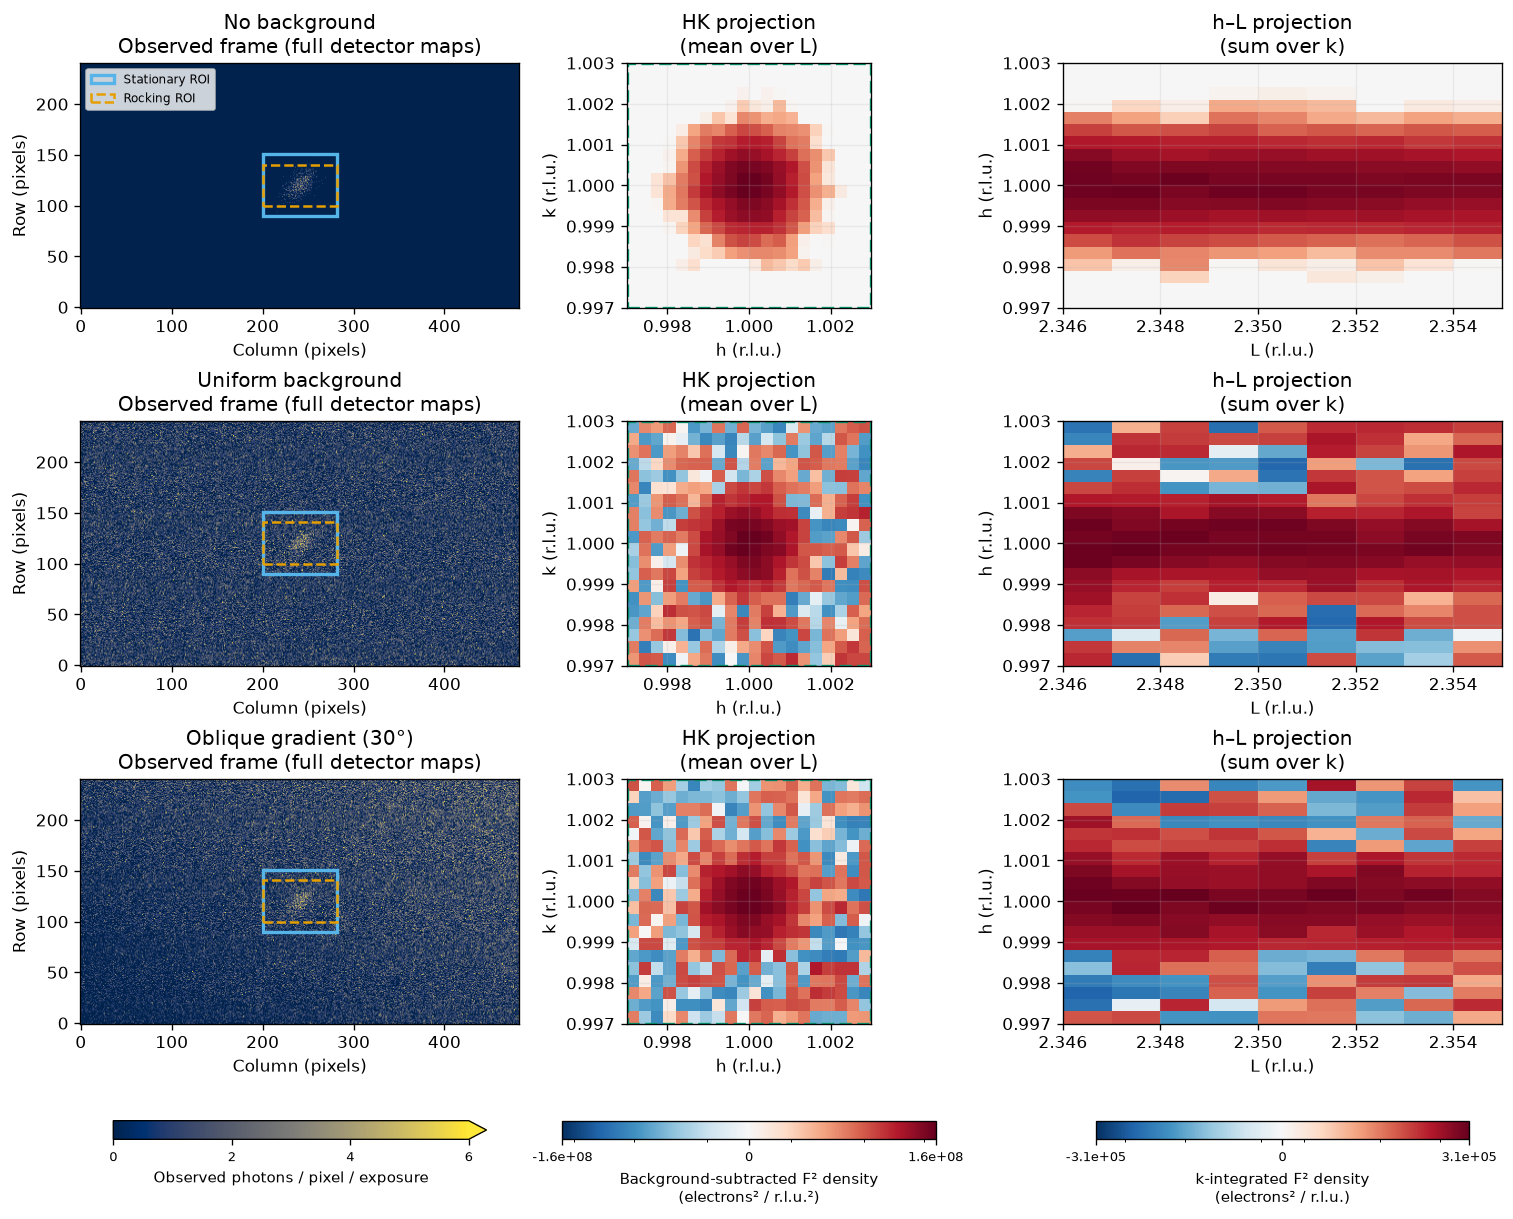

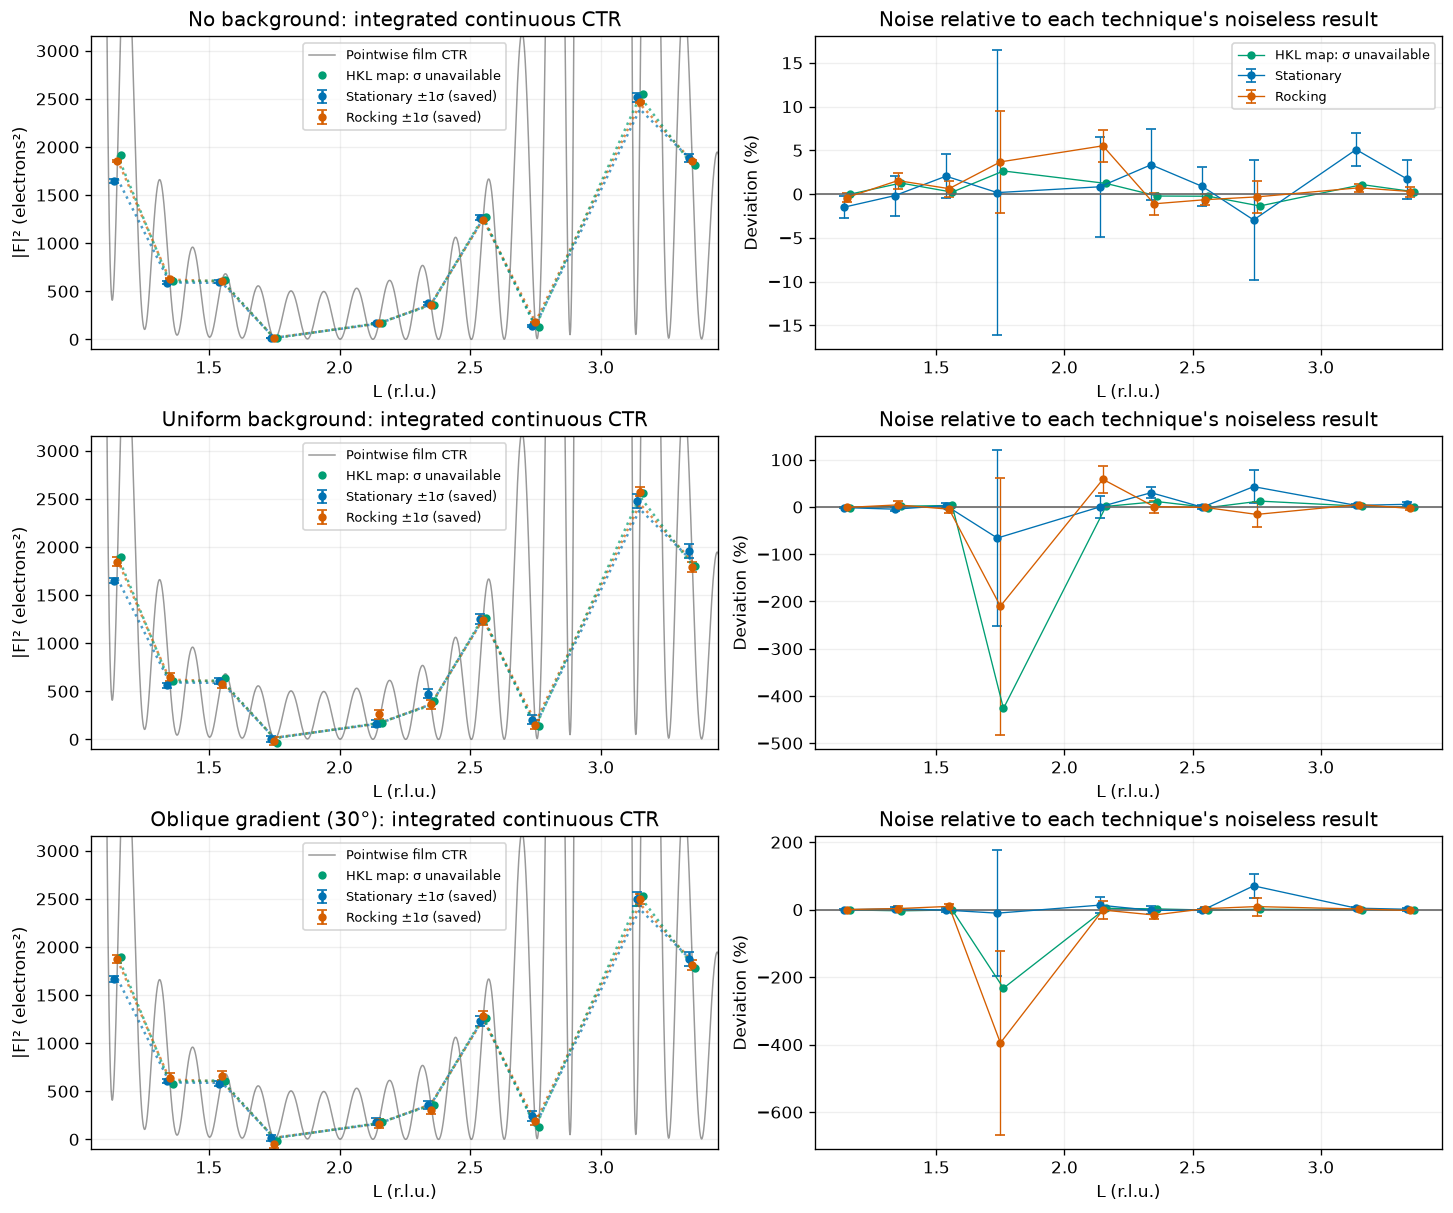

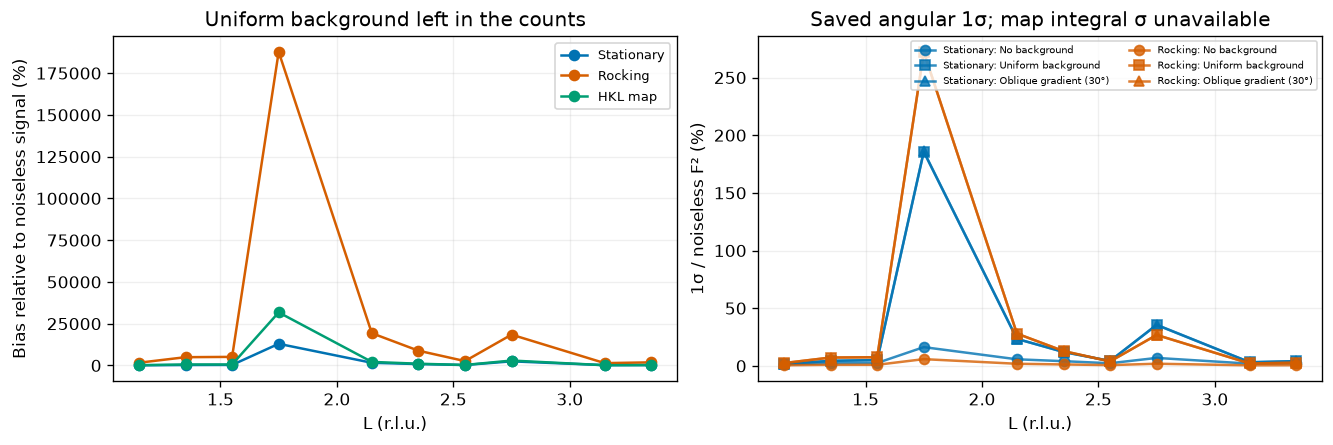

No background: median relative 1σ by path (%) = Stationary 2.40, Rocking 0.93
Uniform background: median relative 1σ by path (%) = Stationary 4.68, Rocking 7.36
Oblique gradient (30°): median relative 1σ by path (%) = Stationary 4.69, Rocking 7.37
HKL map integrated uncertainty: unavailable (not computed by the production API).


In [7]:
from matplotlib.colors import SymLogNorm

STATIONARY_ROI = np.s_[90:151, 201:282]
ROCKING_ROI = np.s_[:, 100:141, 201:282]
NOISE_L = np.array([1.15, 1.35, 1.55, 1.75, 2.15, 2.35, 2.55, 2.75, 3.15, 3.35])
NOISE_PATHS = ["Stationary", "Rocking", "HKL map"]
NOISE_COLORS = ["#0072B2", "#D55E00", "#009E73"]

def _continuous_noise_scan(ell):
    """Generate the varying CTR at the common photon dose used in the frame illustration."""
    data = _simulate((1, 1), ell, float(_f2((1, 1), ell)[0]))
    pixel_f2 = _f2(data.hk, data.l_pixel.ravel()).reshape(data.l_pixel.shape)
    data.raw *= pixel_f2[None, :, :]/data.target*dose_factor
    data.fluence *= dose_factor
    data.scan.exposure_time *= dose_factor
    return data

noise_values = np.zeros((3, len(NOISE_L), 3))
noise_errors = np.full_like(noise_values, np.nan)  # Map integral sigma is unavailable in the implementation.
noise_unsubtracted = np.zeros_like(noise_values)
noise_baselines = np.zeros((len(NOISE_L), 3))
noise_reference_maps = {}
noise_reference_corrected = {}
for point, ell in enumerate(NOISE_L):
    data = noise_reference_data if ell == 2.35 else _continuous_noise_scan(ell)
    noise_baselines[point, :2] = _angular_reduce(data)
    baseline_map = _map_reduce(data, step=.0003, depth=3, l_halfwidth=.004)
    noise_baselines[point, 2] = baseline_map.f2
    draw_rng = np.random.default_rng(8200+point)
    if ell == 2.35:
        cases = observed_reference_cases
    else:
        shared_signal = draw_rng.poisson(data.raw).astype(np.int32)
        cases = {name: shared_signal+draw_rng.poisson(mean, size=data.raw.shape).astype(np.int32)
                 for name, mean in background_means.items()}
    for case, (name, observed) in enumerate(cases.items()):
        mean = background_means[name]
        values, errors = _angular_reduce(data, observed, mean, return_errors=True)
        observed_data = SimpleNamespace(**(vars(data) | {"raw": observed}))
        mapped = _map_reduce(observed_data, step=.0003, depth=3, l_halfwidth=.004, background=mean)
        noise_values[case, point] = [*values, mapped.f2]
        noise_errors[case, point, :2] = errors
        if case == 1:  # Only uniform-background bias is plotted below.
            noise_unsubtracted[case, point, :2] = _angular_reduce(data, observed)
            noise_unsubtracted[case, point, 2] = _map_reduce(
                observed_data, step=.0003, depth=3, l_halfwidth=.004).f2
        if ell == 2.35:
            noise_reference_maps[name] = mapped
            noise_reference_corrected[name] = observed[central_frame]-mean
        print(f"Noisy CTR L={ell:.2f}: {name} reduced through app extraction/reduction and map HDF5 pipeline", flush=True)
    del cases

assert np.all(np.isfinite(noise_values)) and np.all(noise_errors[:, :, :2] > 0)
assert np.all(np.isnan(noise_errors[:, :, 2]))
print("Stationary and rocking: saved production F² and 1σ. HKL map: integrated F², no integral uncertainty returned.")

# Pair the actual noisy stationary image with its actual reciprocal-space volume.
fig, axes = plt.subplots(3, 3, figsize=(12.5, 10), constrained_layout=True)
scale = (2.8179403262e-15)**2/(AREA_ANGSTROM2*1e-20)*noise_reference_data.illumination*noise_reference_data.omega_ref
densities = {name: mapped.volume/scale for name, mapped in noise_reference_maps.items()}
hk_limit = max(np.max(np.abs(values.mean(axis=2))) for values in densities.values())
hl_limit = max(np.max(np.abs(values.sum(axis=1)*.0003)) for values in densities.values())
for row, (name, mapped) in enumerate(noise_reference_maps.items()):
    image = observed_reference_cases[name][central_frame]
    im0 = axes[row, 0].imshow(image, origin="lower", aspect="auto", cmap="cividis", vmin=0, vmax=6)
    axes[row, 0].add_patch(Rectangle((200.5, 89.5), 81, 61, fill=False,
                                    edgecolor="#56B4E9", lw=2, label="Stationary ROI"))
    axes[row, 0].add_patch(Rectangle((200.5, 99.5), 81, 41, fill=False,
                                    edgecolor="#E69F00", lw=1.5, ls="--", label="Rocking ROI"))
    axes[row, 0].set(title=f"{name}\nObserved frame (full detector maps)", xlabel="Column (pixels)", ylabel="Row (pixels)")
    axes[row, 0].grid(False)
    h, k, ell = mapped.axes
    lower = mapped.grid.minimum
    upper = mapped.grid.effective_maximum
    hk_extent = [lower[0], upper[0], lower[1], upper[1]]
    im1 = axes[row, 1].imshow(densities[name].mean(axis=2).T, origin="lower", extent=hk_extent,
                              aspect="equal", cmap="RdBu_r",
                              norm=SymLogNorm(linthresh=hk_limit*.01, vmin=-hk_limit, vmax=hk_limit))
    axes[row, 1].add_patch(Rectangle((lower[0], lower[1]), upper[0]-lower[0], upper[1]-lower[1],
                                    fill=False, edgecolor="#009E73", lw=2, ls="--"))
    axes[row, 1].set(title="HK projection\n(mean over L)", xlabel="h (r.l.u.)", ylabel="k (r.l.u.)")
    hl = densities[name].sum(axis=1)*mapped.grid.step[1]
    im2 = axes[row, 2].imshow(hl, origin="lower", extent=[lower[2], upper[2], lower[0], upper[0]],
                              aspect="auto", cmap="RdBu_r",
                              norm=SymLogNorm(linthresh=hl_limit*.01, vmin=-hl_limit, vmax=hl_limit))
    axes[row, 2].set(title="h–L projection\n(sum over k)", xlabel="L (r.l.u.)", ylabel="h (r.l.u.)")
axes[0, 0].legend(loc="upper left", fontsize=7)
cb0 = fig.colorbar(im0, ax=axes[:, 0], orientation="horizontal", extend="max", shrink=.85, pad=.04)
cb0.set_label("Observed photons / pixel / exposure", fontsize=9)
cb0.set_ticks([0, 2, 4, 6])
cb1 = fig.colorbar(im1, ax=axes[:, 1], orientation="horizontal", shrink=.85, pad=.04)
cb1.set_label("Background-subtracted F² density\n(electrons² / r.l.u.²)", fontsize=9)
cb1.set_ticks([-hk_limit, 0, hk_limit], labels=[f"{-hk_limit:.1e}", "0", f"{hk_limit:.1e}"])
cb2 = fig.colorbar(im2, ax=axes[:, 2], orientation="horizontal", shrink=.85, pad=.04)
cb2.set_label("k-integrated F² density\n(electrons² / r.l.u.)", fontsize=9)
cb2.set_ticks([-hl_limit, 0, hl_limit], labels=[f"{-hl_limit:.1e}", "0", f"{hl_limit:.1e}"])
for colorbar in (cb0, cb1, cb2):
    colorbar.ax.tick_params(labelsize=8)
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for case, name in enumerate(background_means):
    axes[case, 0].plot(L_CURVE, curve_f2[(1, 1)], color="black", alpha=.4, lw=.9, label="Pointwise film CTR")
    for mode, (path, color) in enumerate(zip(NOISE_PATHS, NOISE_COLORS)):
        shift = (mode-1)*.012
        axes[case, 0].plot(NOISE_L, noise_baselines[:, mode], color=color, ls=":", alpha=.7)
        residual = 100*(noise_values[case, :, mode]/noise_baselines[:, mode]-1)
        if mode < 2:
            axes[case, 0].errorbar(NOISE_L+shift, noise_values[case, :, mode],
                                  yerr=noise_errors[case, :, mode], fmt="o", ms=4, capsize=3,
                                  color=color, label=path+" ±1σ (saved)")
            axes[case, 1].errorbar(NOISE_L+shift, residual,
                                  yerr=100*noise_errors[case, :, mode]/noise_baselines[:, mode],
                                  fmt="o-", ms=4, lw=.8, capsize=3, color=color, label=path)
        else:
            axes[case, 0].plot(NOISE_L+shift, noise_values[case, :, mode], "o", ms=4,
                               color=color, label="HKL map: σ unavailable")
            axes[case, 1].plot(NOISE_L+shift, residual, "o-", ms=4, lw=.8,
                               color=color, label="HKL map: σ unavailable")
    # Dense CTR Bragg poles are outside this range of sampled intensities.
    axes[case, 0].set(xlim=(1.05, 3.45), ylim=(-100, 1.2*np.nanmax(noise_values+np.nan_to_num(noise_errors))),
                       title=name+": integrated continuous CTR", xlabel="L (r.l.u.)",
                       ylabel="|F|² (electrons²)")
    axes[case, 1].axhline(0, color="0.4", lw=1)
    axes[case, 1].set(title="Noise relative to each technique's noiseless result",
                       xlabel="L (r.l.u.)", ylabel="Deviation (%)")
    axes[case, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8)
plt.show()

# Show why the mean background must be removed separately from its variance.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for mode, (path, color) in enumerate(zip(NOISE_PATHS, NOISE_COLORS)):
    axes[0].plot(NOISE_L, 100*(noise_unsubtracted[1, :, mode]/noise_baselines[:, mode]-1),
                  "o-", color=color, label=path)
    for case, marker in enumerate(["o", "s", "^"]) if mode < 2 else []:
        axes[1].plot(NOISE_L, 100*noise_errors[case, :, mode]/noise_baselines[:, mode],
                      marker+"-", color=color, alpha=.8,
                      label=path+": "+list(background_means)[case])
axes[0].set(title="Uniform background left in the counts", xlabel="L (r.l.u.)",
             ylabel="Bias relative to noiseless signal (%)")
axes[0].legend(fontsize=8)
axes[1].set(title="Saved angular 1σ; map integral σ unavailable", xlabel="L (r.l.u.)",
             ylabel="1σ / noiseless F² (%)")
axes[1].legend(fontsize=6, ncol=2)
plt.show()
for case, name in enumerate(background_means):
    print(name+": median relative 1σ by path (%) = "+
          ", ".join(f"{path} {np.median(100*noise_errors[case, :, mode]/noise_baselines[:, mode]):.2f}"
                    for mode, path in enumerate(NOISE_PATHS[:2])))
print("HKL map integrated uncertainty: unavailable (not computed by the production API).")


## Noiseless normalization control and finite ROI capture

The original local-constant, two-rod control used the complete detector for the
stationary measurement. Here it is run through the actual app with a
483 × 241 stationary ROI; the rocking aperture is still 81 × 41 pixels.
All three inputs are the same expected-count dataset, and no measured output
is rescaled. This tests normalization when the transverse signal is captured.

The actual stationary result for the smaller 81 × 61 ROI used in the noise
study is also plotted, together with its fraction of captured detector counts.
This aperture can truncate the (2,0,L) rod; its deficit is retained explicitly,
not corrected away. Equal structure factors require comparable peak capture
as well as compatible L resolution.


In [8]:
L_TEST = np.array([1.15, 1.35, 1.55, 1.75, 2.15, 2.35, 2.55, 2.75, 3.15, 3.35])
records, example_data, example_map = [], None, None
for hk in RODS:
    for ell in L_TEST:
        target = float(_f2(hk, ell)[0])
        data = (illustration_data if hk == (1, 1) and ell == 2.35
                else _simulate(hk, ell, target))
        stationary, rocking = _angular_reduce(data, stationary_full=True)
        finite_stationary = _angular_reduce(data)[0]
        central = data.raw[len(data.scan)//2]
        capture_fraction = central[90:151, 201:282].sum()/central.sum()
        mapped = _map_reduce(data)
        records.append((hk, ell, target, stationary, rocking, mapped.f2, finite_stationary, capture_fraction))
        if hk == (1, 1) and ell == 2.35:
            example_data, example_map = data, mapped
    print(f"Completed ({hk[0]}, {hk[1]}, L): {len(L_TEST)} detector scans and HKL maps")

results = np.array([row[1:] for row in records], dtype=float)
relative_error = results[:, 2:5]/results[:, 1, None]-1
print("Maximum absolute relative error by path:")
for name, value in zip(("stationary", "rocking", "HKL map"), np.max(np.abs(relative_error), axis=0)):
    print(f"  {name:12s}: {100*value:.5f}%")
np.testing.assert_allclose(results[:, 2:5], np.broadcast_to(results[:, 1, None], (len(results), 3)), rtol=1e-3)
print("Smaller stationary ROI: maximum F² deficit = "
      f"{100*np.max(1-results[:, 5]/results[:, 1]):.2f}%; "
      f"minimum captured detector counts = {100*np.min(results[:, 6]):.2f}%")


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


...

C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


Completed (1, 1, L): 10 detector scans and HKL maps
Maximum absolute relative error by path:
  stationary  : 0.01573%
  rocking     : 0.01477%
  HKL map     : 0.00730%
Smaller stationary ROI: maximum F² deficit = 29.95%; minimum captured detector counts = 70.04%


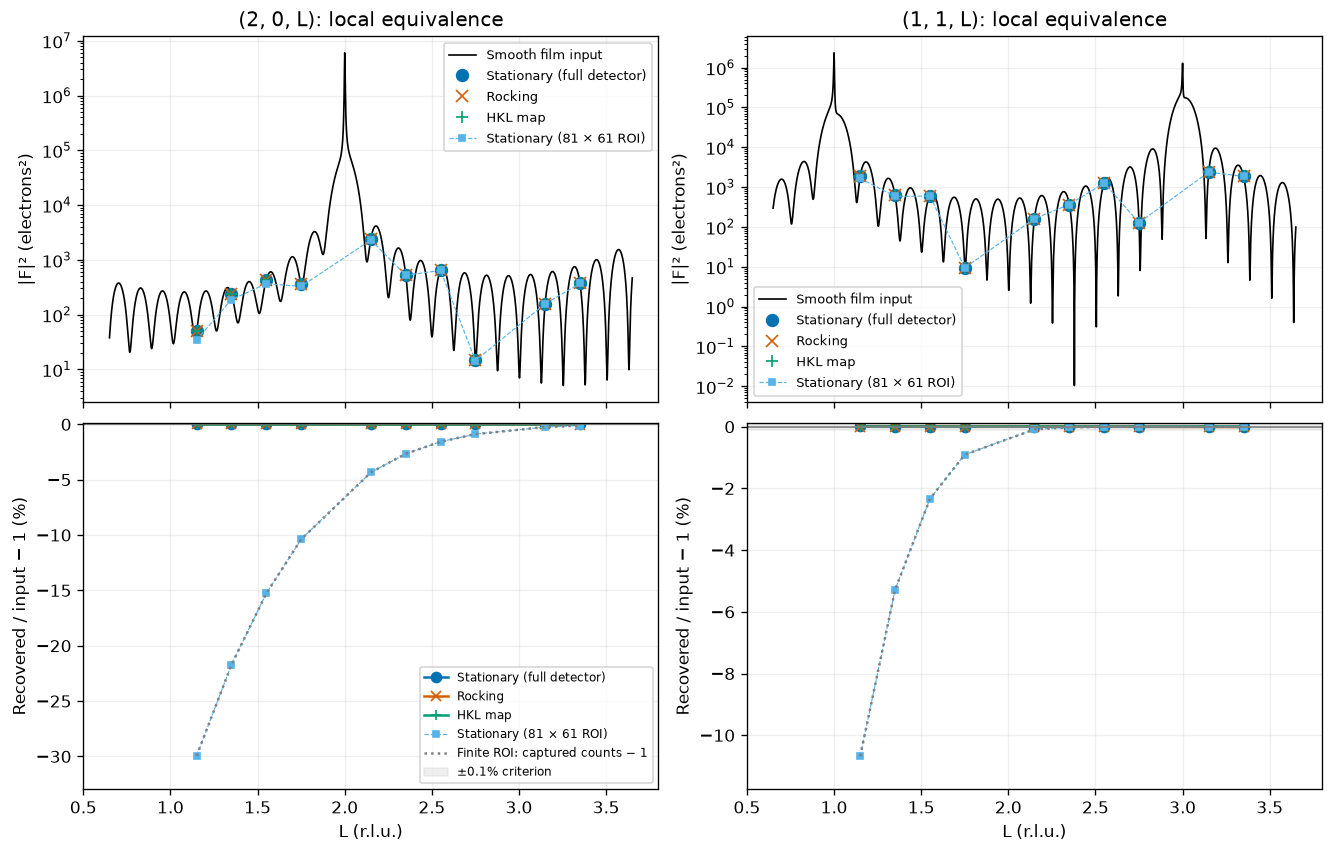

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True, sharex="col")
styles = [("Stationary (full detector)", "o", "#0072B2"), ("Rocking", "x", "#D55E00"), ("HKL map", "+", "#009E73")]
for column, hk in enumerate(RODS):
    subset = results[np.array([row[0] == hk for row in records])]
    axes[0, column].semilogy(L_CURVE, curve_f2[hk], "k-", lw=1, label="Smooth film input")
    for j, (label, marker, color) in enumerate(styles):
        axes[0, column].semilogy(subset[:, 0], subset[:, j+2], marker, color=color, ms=7, label=label)
        axes[1, column].plot(subset[:, 0], 100*(subset[:, j+2]/subset[:, 1]-1), marker+"-", color=color, label=label)
    axes[0, column].semilogy(subset[:, 0], subset[:, 5], "s--", color="#56B4E9",
                              ms=4, lw=.7, label="Stationary (81 × 61 ROI)")
    axes[1, column].plot(subset[:, 0], 100*(subset[:, 5]/subset[:, 1]-1), "s--",
                         color="#56B4E9", ms=4, lw=.7, label="Stationary (81 × 61 ROI)")
    axes[1, column].plot(subset[:, 0], 100*(subset[:, 6]-1), ":", color="0.5",
                         label="Finite ROI: captured counts − 1")
    axes[0, column].set(title=f"({hk[0]}, {hk[1]}, L): local equivalence", ylabel="|F|² (electrons²)")
    axes[0, column].legend(fontsize=8)
    axes[1, column].axhline(0, color="0.5", lw=1)
    axes[1, column].axhspan(-0.1, 0.1, color="0.8", alpha=0.3, label="±0.1% criterion")
    axes[1, column].set(xlabel="L (r.l.u.)", ylabel="Recovered / input − 1 (%)", ylim=(min(-0.12, 110*np.min(subset[:, 5]/subset[:, 1]-1)), 0.12))
axes[1, 0].legend(fontsize=7)
plt.show()

## Inspect the synthetic measurement and map

The detector frame, normalized rocking trace, HKL cross-section and coverage
below all belong to the $(1,1,2.35)$ sample above. Intensities on the detector
are photons per exposure; the map is normalized photons per incident photon,
with polarization and **relative** solid angle removed. $H$ and
$\Omega_\mathrm{ref}$ are divided out only when the map is integrated.

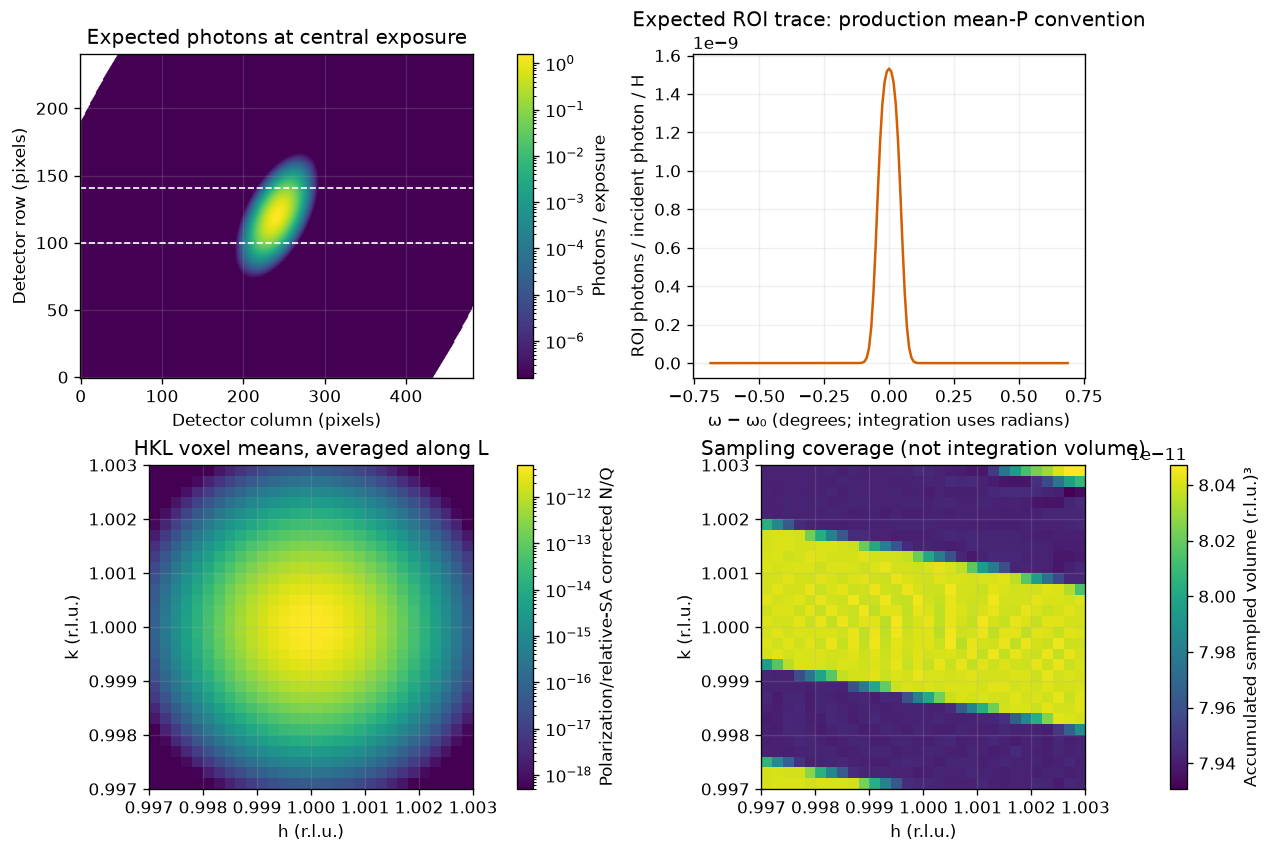

In [10]:
data, mapped = example_data, example_map
middle = len(data.scan)//2
normalized_curve = _expected_roi_trace(data)
image = data.raw[middle]
projection = mapped.volume.mean(axis=2)
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7), constrained_layout=True)
im = axes[0, 0].imshow(image, origin="lower", norm=LogNorm(vmin=image.max()*1e-7, vmax=image.max()), aspect="auto")
axes[0, 0].axhline(99.5, color="white", ls="--", lw=1)
axes[0, 0].axhline(140.5, color="white", ls="--", lw=1)
axes[0, 0].set(title="Expected photons at central exposure", xlabel="Detector column (pixels)", ylabel="Detector row (pixels)")
fig.colorbar(im, ax=axes[0, 0], label="Photons / exposure")
axes[0, 1].plot(np.rad2deg(data.axis), normalized_curve, color="#D55E00")
axes[0, 1].set(title="Expected ROI trace: production mean-P convention", xlabel="ω − ω₀ (degrees; integration uses radians)", ylabel="ROI photons / incident photon / H")
h, k, l = mapped.axes
extent = [h[0]-0.0001, h[-1]+0.0001, k[0]-0.0001, k[-1]+0.0001]
im = axes[1, 0].imshow(projection.T, origin="lower", extent=extent, aspect="equal", norm=LogNorm(vmin=projection.max()*1e-7, vmax=projection.max()))
axes[1, 0].set(title="HKL voxel means, averaged along L", xlabel="h (r.l.u.)", ylabel="k (r.l.u.)")
fig.colorbar(im, ax=axes[1, 0], label="Polarization/relative-SA corrected N/Q")
im = axes[1, 1].imshow(mapped.weight.sum(axis=2).T, origin="lower", extent=extent, aspect="equal")
axes[1, 1].set(title="Sampling coverage (not integration volume)", xlabel="h (r.l.u.)", ylabel="k (r.l.u.)")
fig.colorbar(im, ax=axes[1, 1], label="Accumulated sampled volume (r.l.u.)³")
plt.show()

## Footprint depth, grid refinement and repeated acquisition

The selected HKL integral must be stable under footprint and grid refinement.
The primary comparison uses footprint depth 4. Shallower splitting can bias
the voxel integral even when every voxel has contributors: nonzero coverage
alone does not establish quadrature convergence. The first plot checks this
on the (2,0,2.35) reflection before inspecting the voxel grid itself. Repeating the
same acquisition should increase sampling weights, while preserving voxel means
and the recovered structure factor. Neither grid width nor repetition is used
to fit a scale.

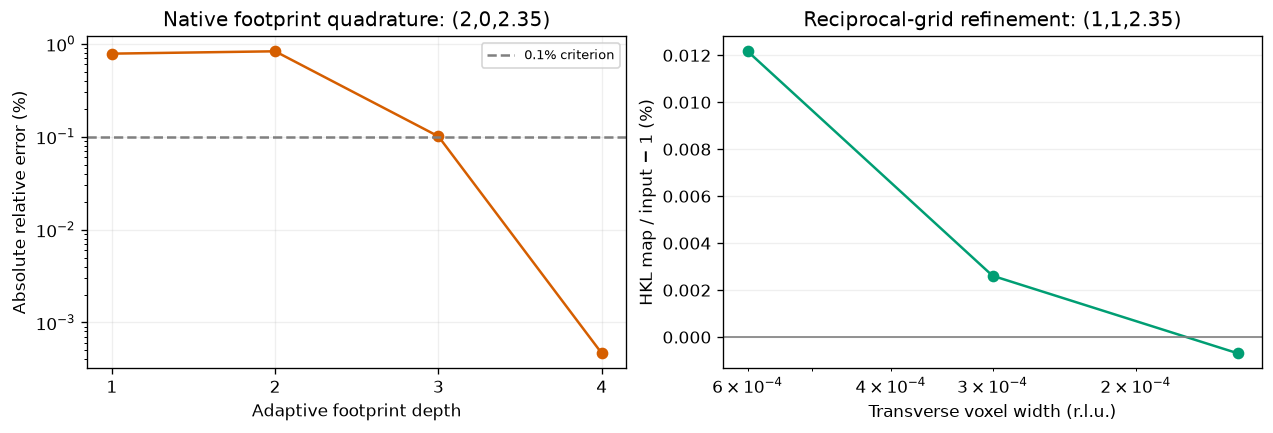

Repeated / single F²: 1.000000000000
Repeated / single sampling weight: 2.000000000000


In [11]:
steps = np.array([0.0006, 0.0003, 0.00015])
refined = [_map_reduce(example_data, step=step) for step in steps]
repeated = _map_reduce(example_data, repeats=2)
np.testing.assert_allclose(repeated.f2, example_map.f2, rtol=1e-12)
np.testing.assert_allclose(repeated.weight, 2*example_map.weight, rtol=1e-12)
np.testing.assert_allclose([item.f2 for item in refined], example_data.target, rtol=1e-3)
depth_data = _simulate((2, 0), 2.35, float(_f2((2, 0), 2.35)[0]))
depths = [1, 2, 3, 4]
depth_values = [_map_reduce(depth_data, depth=depth).f2 for depth in depths]
np.testing.assert_allclose(depth_values[-1], depth_data.target, rtol=1e-3)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5), constrained_layout=True)
axes[0].semilogy(depths, 100*np.abs(np.array(depth_values)/depth_data.target-1), "o-", color="#D55E00")
axes[0].axhline(0.1, color="0.5", ls="--", label="0.1% criterion")
axes[0].set(xticks=depths, xlabel="Adaptive footprint depth", ylabel="Absolute relative error (%)", title="Native footprint quadrature: (2,0,2.35)")
axes[0].legend(fontsize=8)
axes[1].plot(steps, [100*(item.f2/example_data.target-1) for item in refined], "o-", color="#009E73")
axes[1].axhline(0, color="0.5", lw=1)
axes[1].set(xscale="log", xlabel="Transverse voxel width (r.l.u.)", ylabel="HKL map / input − 1 (%)", title="Reciprocal-grid refinement: (1,1,2.35)")
axes[1].invert_xaxis()
plt.show()
print(f"Repeated / single F²: {repeated.f2/example_map.f2:.12f}")
print(f"Repeated / single sampling weight: {repeated.weight.sum()/example_map.weight.sum():.12f}")

## Restore the real CTR variation within the aperture

The local control above holds a film-derived $F^2(L_0)$ constant. Now use
$F^2(L_p)$ on every detector pixel instead. For this fixed-incidence, zero-χ/φ
rocking geometry, L does not change under the ω rotation, so multiplying the
existing frames by $F^2(L_p)/F^2(L_0)$ restores that dependence exactly for the
chosen rod-density model. A dense model curve supplies linear interpolation in L.

The three measurement apertures have different L responses. The plot below
shows their normalized kernels and compares each output with its expected
resolution average. Kernel normalization predicts the resolution effect; it
does **not** rescale any recovered structure factor. The HKL reference is a
uniform integral over the actual selected L voxel edges, not a fitted factor.

C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: divide by zero encountered in divide
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1802: RuntimeWarning: invalid value encountered in multiply
  croibg2_a = croi2_a * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: divide by zero encountered in divide
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)
C:\Users\timof\Documents\repos\orGUI\orgui\app\scan_integration.py:1803: RuntimeWarning: invalid value encountered in multiply
  croibg2_err_a = np.sqrt(croi2_a) * (roi_size2 / cpixel2_a)


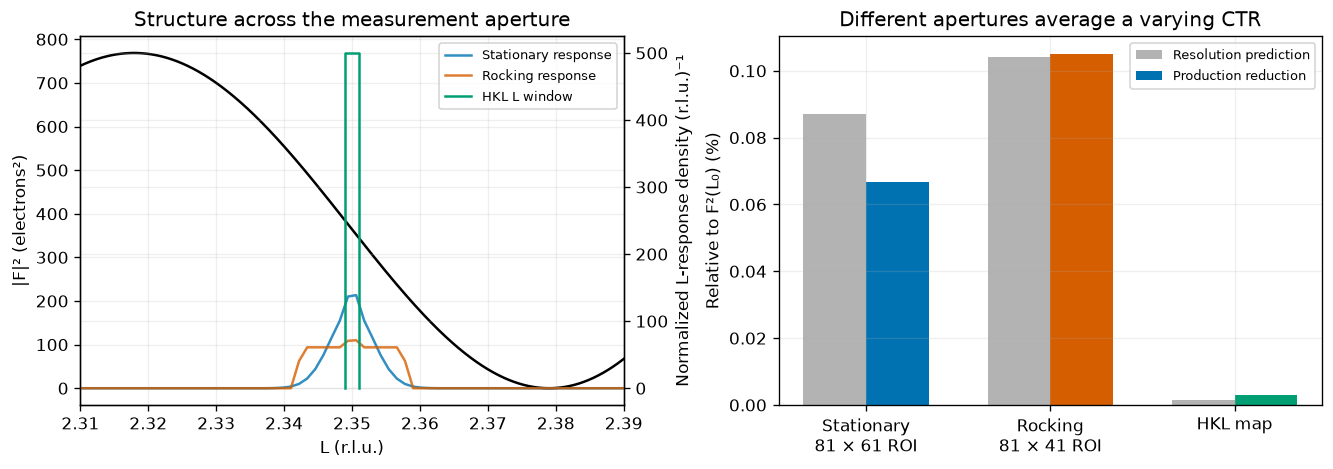

Path,Recovered F²,Resolution prediction,Difference
Stationary 81 × 61 ROI,364.531,364.604,-0.0201%
Rocking 81 × 41 ROI,364.67,364.666,+0.0011%
HKL map,364.299,364.292,+0.0017%


In [7]:
local = example_data
resolution_labels = ["Stationary\n81 × 61 ROI", "Rocking\n81 × 41 ROI", "HKL map"]
fine_l = np.linspace(float(local.l_pixel.min())-0.01, float(local.l_pixel.max())+0.01, 8001)
fine_f2 = _f2(local.hk, fine_l)
pixel_f2 = np.interp(local.l_pixel, fine_l, fine_f2)
continuous = SimpleNamespace(**(vars(local) | {"raw": local.raw*pixel_f2[None, :, :]/local.target}))
varying_stationary, varying_rocking = _angular_reduce(continuous)
varying_map = _map_reduce(continuous)

unit_pixels = local.raw/local.fluence[:, None, None]/local.target
stationary_kernel = unit_pixels[len(local.scan)//2][90:151, 201:282]
rocking_kernel = np.trapezoid(unit_pixels[:, 100:141, 201:282], local.axis, axis=0)
expected_stationary = np.sum(stationary_kernel*pixel_f2[90:151, 201:282])/stationary_kernel.sum()
expected_rocking = np.sum(rocking_kernel*pixel_f2[100:141, 201:282])/rocking_kernel.sum()
lower = varying_map.grid.minimum[2]
upper = lower + varying_map.volume.shape[2]*varying_map.grid.step[2]
map_l = np.linspace(lower, upper, 1001)
expected_map = np.trapezoid(np.interp(map_l, fine_l, fine_f2), map_l)/(upper-lower)
predictions = np.array([expected_stationary, expected_rocking, expected_map])
recovered = np.array([varying_stationary, varying_rocking, varying_map.f2])

bins = np.linspace(local.ell-0.06, local.ell+0.06, 101)
centers, widths = (bins[:-1]+bins[1:])/2, np.diff(bins)
stat_hist = np.histogram(local.l_pixel[90:151, 201:282], bins=bins, weights=stationary_kernel)[0]
rock_hist = np.histogram(local.l_pixel[100:141, 201:282], bins=bins, weights=rocking_kernel)[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].plot(fine_l, fine_f2, color="black", label="Smooth film F²(L)")
axes[0].set(xlim=(local.ell-0.04, local.ell+0.04), xlabel="L (r.l.u.)", ylabel="|F|² (electrons²)", title="Structure across the measurement aperture")
kernel_ax = axes[0].twinx()
kernel_ax.plot(centers, stat_hist/stat_hist.sum()/widths, color="#0072B2", alpha=0.8, label="Stationary response")
kernel_ax.plot(centers, rock_hist/rock_hist.sum()/widths, color="#D55E00", alpha=0.8, label="Rocking response")
kernel_ax.plot([lower, lower, upper, upper], [0, 1/(upper-lower), 1/(upper-lower), 0], color="#009E73", label="HKL L window")
kernel_ax.set(ylabel="Normalized L-response density (r.l.u.)⁻¹")
kernel_ax.legend(loc="upper right", fontsize=8)
positions = np.arange(3)
axes[1].bar(positions-0.17, 100*(predictions/local.target-1), width=0.34, color="0.7", label="Resolution prediction")
axes[1].bar(positions+0.17, 100*(recovered/local.target-1), width=0.34, color=[item[2] for item in styles], label="Production reduction")
axes[1].set(xticks=positions, xticklabels=resolution_labels, ylabel="Relative to F²(L₀) (%)", title="Different apertures average a varying CTR")
axes[1].legend(fontsize=8)
plt.show()

rows = "".join(f"<tr><td>{name}</td><td>{value:.6g}</td><td>{prediction:.6g}</td><td>{100*(value/prediction-1):+.4f}%</td></tr>"
               for name, value, prediction in zip(resolution_labels, recovered, predictions))
display(HTML("<table><thead><tr><th>Path</th><th>Recovered F²</th><th>Resolution prediction</th><th>Difference</th></tr></thead><tbody>"+rows+"</tbody></table>"))
np.testing.assert_allclose(recovered, predictions, rtol=2e-3)

## Interpretation and limits

The flat-film CTR values provide a nonconstant sequence of input structure
factors. In the local equivalence control, all three integration paths recover
that sequence on one scale when the full stationary detector aperture is used.
The smaller stationary ROI can truncate the (2,0,L) peak; both its deficit
and the fraction of captured counts are displayed without compensation. Repeated mapping does not double its structure
factor, and changing voxel width does not introduce a volume scale error.

Restoring variation inside the aperture compares different resolution averages;
agreement with a single point value requires matched resolution, narrower
apertures or a locally constant CTR. This distinction matters near sharp film
fringes and substrate Bragg peaks. No physical roughness was introduced to
make the comparison easier.

The equivalence check assumes a kinematic, fully captured rod, known polarization, no
detector inefficiency or transmission loss, and constant illumination. A varying
illumination divisor must be applied **before mapping**. Missing coverage and
finite peak capture must be addressed explicitly. The map's saved marginal voxel variances do not contain splitting covariance.
The production map integration API returns no integrated uncertainty, so this
notebook does not supply one. Angular error bars are read from saved app results.
The unused native `backproject_coefficients` prototype remains in the source
as a reminder, pending production integration and validation.

Related documentation: [image integration](image_integration.rst),
[reciprocal-space reconstruction](reciprocal_space_reconstruction.rst), and
[CTR structure-factor units](ctr_structure_factors.rst).
The HKL integral follows [Drnec et al. (2014), equation 14](https://doi.org/10.1107/S1600576713032342);
the angular factors follow [Vlieg (1997)](https://doi.org/10.1107/S0021889897002537).
